# HydrAI: ML Training Data Generation

This notebook generates training datasets for ML surrogate models by running multiple PFR simulations with varied parameters.

## Overview

The data generation process:
1. **Parameter Sweep**: Varies 6 key parameters (temperature, pressure, geometry, flow, heat flux)
2. **Multiple Reactants**: Supports ethane, propane, naphtha, n-hexane
3. **Efficient Collection**: Disables plots/CSV exports for speed
4. **Periodic Saves**: Saves data incrementally to prevent loss
5. **Rich Features**: Collects 245+ features per simulation point

## Features
- Configurable parameter ranges
- Random sampling for large parameter spaces
- Progress tracking and time estimates
- Automatic data validation
- Metadata export for reproducibility

In [ ]:
# Setup and Imports
import sys
import os
from pathlib import Path
import json
import numpy as np
import pandas as pd
import time
from datetime import datetime

# Get project root directory
current_dir = Path(os.getcwd())
if (current_dir / 'src').exists():
    project_root = current_dir
elif (current_dir.parent / 'src').exists():
    project_root = current_dir.parent
else:
    project_root = current_dir

# IMPORTANT: Import cantera BEFORE adding src to sys.path
# This prevents namespace conflict: without this, Python would find src/cantera/
# (our package) instead of the actual cantera library
import cantera as ct
print(f"Cantera version: {ct.__version__}")

# Suppress all Cantera/SUNDIALS warnings and messages
import warnings
import logging
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', message='.*rank.*')
warnings.filterwarnings('ignore', message='.*CVode.*')
warnings.filterwarnings('ignore', message='.*SUNDIALS.*')
warnings.filterwarnings('ignore', message='.*WARNING.*')
logging.getLogger('cantera').setLevel(logging.CRITICAL)
logging.getLogger('sundials').setLevel(logging.CRITICAL)

# Add src to path (after cantera is imported)
sys.path.insert(0, str(project_root / 'src'))

from src.ml.data_generation import TrainingDataGenerator

print("HydrAI: ML Training Data Generation")
print("=" * 60)
print(f"Project root: {project_root}")


Cantera version: 3.2.0
HydrAI: ML Training Data Generation
Project root: /Users/nikolaskarefyllidis/Desktop/60_ML:AI/30 main portofolio projects/HydrAI


## Step 1: Configuration

Configure the data generation parameters. You can either:
- Load from a JSON config file
- Set parameters directly in the notebook

In [2]:
# Option 1: Load from JSON config file
USE_CONFIG_FILE = True  # Set to False to use manual configuration below
CONFIG_FILE = 'configs/ml_data_generation_config.json'

if USE_CONFIG_FILE and Path(CONFIG_FILE).exists():
    with open(CONFIG_FILE, 'r') as f:
        config = json.load(f)
    print(f"[OK] Loaded configuration from: {CONFIG_FILE}")
    
    # Extract parameters
    REACTANTS = config.get('reactants', ['ethane'])
    MAX_COMBINATIONS = config.get('max_combinations_per_reactant', 100)
    OUTPUT_DIR = config.get('output_dir', 'data/training')
    SAVE_INTERVAL = config.get('save_interval', 10)
    RANDOM_SAMPLE = config.get('random_sample', True)
    PARAM_RANGES = config.get('parameter_ranges', {})
    
    print(f"  - Reactants: {REACTANTS}")
    print(f"  - Max combinations per reactant: {MAX_COMBINATIONS}")
    print(f"  - Output directory: {OUTPUT_DIR}")
    print(f"  - Random sampling: {RANDOM_SAMPLE}")
else:
    # Option 2: Manual configuration
    REACTANTS = ['ethane', 'propane']  # List of reactants to use
    MAX_COMBINATIONS = 100  # Maximum parameter combinations per reactant
    OUTPUT_DIR = 'data/training'  # Where to save training data
    SAVE_INTERVAL = 10  # Save every N simulations
    RANDOM_SAMPLE = True  # Randomly sample combinations (recommended for large spaces)
    
    # Parameter ranges: [min, max, n_points]
    PARAM_RANGES = {
        'temperature_K': [800, 1200, 10],
        'pressure_bar': [1.5, 3.0, 8],
        'length_m': [3.0, 7.0, 6],
        'diameter_mm': [20.0, 40.0, 5],
        'mass_flow_rate_kgps': [0.05, 0.10, 6],
        'heat_flux_Wm2': [100000, 200000, 5]
    }
    print("[OK] Using manual configuration")
    print(f"  - Reactants: {REACTANTS}")
    print(f"  - Max combinations per reactant: {MAX_COMBINATIONS}")

print(f"\nParameter Ranges:")
for param, values in PARAM_RANGES.items():
    if isinstance(values, list) and len(values) == 3:
        print(f"  - {param}: {values[0]} to {values[1]} ({values[2]} points)")
    else:
        print(f"  - {param}: {values}")

[OK] Loaded configuration from: configs/ml_data_generation_config.json
  - Reactants: ['n-hexane']
  - Max combinations per reactant: 10
  - Output directory: data/training
  - Random sampling: True

Parameter Ranges:
  - temperature_K: 800 to 900 (10 points)
  - pressure_bar: 1.5 to 3.0 (10 points)
  - length_m: 8.0 to 15.0 (10 points)
  - diameter_mm: 20.0 to 40.0 (10 points)
  - mass_flow_rate_kgps: 0.05 to 0.1 (10 points)
  - heat_flux_Wm2: 100000 to 200000 (10 points)


## Step 2: Initialize Data Generator

Create the data generator with your configuration.

In [3]:
# Initialize generator
generator = TrainingDataGenerator(output_dir=OUTPUT_DIR, disable_plots=True)

# Update parameter ranges from config
if PARAM_RANGES:
    for key, value in PARAM_RANGES.items():
        if isinstance(value, list) and len(value) == 3:
            # Convert [min, max, n_points] to numpy array
            generator.param_ranges[key] = np.linspace(value[0], value[1], value[2])
            print(f"[OK] Updated {key}: {len(generator.param_ranges[key])} points")

# Calculate total combinations
total_combinations = generator._calculate_total_combinations()
print(f"\n[OK] Data generator initialized")
print(f"  - Output directory: {generator.output_dir}")
print(f"  - Total possible combinations: {total_combinations:,}")
print(f"  - Will generate: {len(REACTANTS) * MAX_COMBINATIONS:,} simulations")

Training data will be saved to: data/training
Total parameter combinations: 288000
[OK] Updated temperature_K: 10 points
[OK] Updated pressure_bar: 10 points
[OK] Updated length_m: 10 points
[OK] Updated diameter_mm: 10 points
[OK] Updated mass_flow_rate_kgps: 10 points
[OK] Updated heat_flux_Wm2: 10 points

[OK] Data generator initialized
  - Output directory: data/training
  - Total possible combinations: 4,000,000
  - Will generate: 10 simulations


## Step 3: Generate Training Data

Run the data generation process. This will:
- Run multiple PFR simulations with varied parameters
- Collect features and targets at each simulation point
- Save data incrementally to prevent loss
- Generate metadata for reproducibility

**Note**: This may take 5-30 minutes depending on the number of simulations.

In [4]:
# Generate dataset
print("=" * 60)
print("Starting Training Data Generation...")
print("=" * 60)
print(f"Reactants: {REACTANTS}")
print(f"Max combinations per reactant: {MAX_COMBINATIONS}")
print(f"Random sampling: {RANDOM_SAMPLE}")
print(f"Save interval: {SAVE_INTERVAL} simulations")
print("=" * 60)

start_time = time.time()

dataset = generator.generate_dataset(
    reactants=REACTANTS,
    max_combinations_per_reactant=MAX_COMBINATIONS,
    random_sample=RANDOM_SAMPLE,
    save_interval=SAVE_INTERVAL
)

elapsed_time = time.time() - start_time
hours = int(elapsed_time // 3600)
minutes = int((elapsed_time % 3600) // 60)
seconds = int(elapsed_time % 60)

print(f"\n[OK] Data generation completed!")
print(f"  - Total time: {hours:02d}:{minutes:02d}:{seconds:02d}")

# Calculate actual number of simulations completed
# The dataset has multiple rows per simulation (one per reactor step)
# We get the actual count from the metadata file
if dataset is not None and len(dataset) > 0:
    import glob
    metadata_files = sorted(glob.glob(str(generator.output_dir / 'metadata_*.json')), reverse=True)
    if metadata_files:
        with open(metadata_files[0], 'r') as f:
            metadata = json.load(f)
        n_simulations = metadata.get('total_simulations', len(REACTANTS) * MAX_COMBINATIONS)
    else:
        n_simulations = len(REACTANTS) * MAX_COMBINATIONS
    
    print(f"  - Simulations completed: {n_simulations}")
    print(f"  - Data points collected: {len(dataset):,}")
    if n_simulations > 0:
        print(f"  - Average time per simulation: {elapsed_time / n_simulations:.2f} seconds")
        print(f"  - Data points per simulation: {len(dataset) / n_simulations:.1f}")
    else:
        print("  - Average time: N/A (no simulations completed)")
else:
    print("  - Average time: N/A (no data collected)")


Starting Training Data Generation...
Reactants: ['n-hexane']
Max combinations per reactant: 10
Random sampling: True
Save interval: 10 simulations

Generating training data for 1 reactants
  10 parameter combinations per reactant
  Total simulations: 10

Processing reactant: n-hexane

[1] Running simulation for n-hexane...
  T=900.0K, P=2.83bar, L=13.4m, D=24.4mm, m=0.0667kg/s, q=111111W/m²
Gas mechanism contains 153 species and 2146 reactions
Starting simulation with 200 steps...
Progress: 0/200 (0%)
Progress: 20/200 (10%)
Progress: 40/200 (20%)
[WARNING][rank 0][/Users/runner/work/_temp/sundials-7.4.0/src/cvodes/cvodes.c:3528][CVode] Internal t = 2476816.13596791 and h = 2.27991886622812e-10 are such that t + h = t on the next step. The solver will continue anyway.
[WARNING][rank 0][/Users/runner/work/_temp/sundials-7.4.0/src/cvodes/cvodes.c:3528][CVode] Internal t = 2476816.13596791 and h = 2.27991886622812e-10 are such that t + h = t on the next step. The solver will continue anywa

## Step 4: Dataset Summary

Display information about the generated dataset.

In [5]:
if dataset is not None:
    print("=" * 60)
    print("DATASET SUMMARY")
    print("=" * 60)
    print(f"Shape: {dataset.shape[0]:,} rows × {dataset.shape[1]} columns")
    print(f"\nColumn Categories:")
    
    # Count different types of columns
    input_cols = [c for c in dataset.columns if c in ['temperature_K', 'pressure_Pa', 
                                                       'reactor_length_m', 'reactor_diameter_m',
                                                       'mass_flow_rate_kgps', 'heat_flux_Wm2', 'z_position_m']]
    output_cols = [c for c in dataset.columns if c in ['velocity_ms', 'density_kgm3']]
    species_cols = [c for c in dataset.columns if c.startswith('Y_') or c.startswith('X_')]
    
    print(f"  - Input features: {len(input_cols)}")
    print(f"  - Output targets: {len(output_cols)}")
    print(f"  - Species data: {len(species_cols)} (mass + mole fractions)")
    print(f"  - Total columns: {len(dataset.columns)}")
    
    print(f"\nData Statistics:")
    print(dataset[['temperature_K', 'pressure_Pa', 'velocity_ms', 'density_kgm3']].describe())
    
    print(f"\n[OK] Dataset ready for ML training!")
    print(f"  - Saved to: {generator.output_dir}")
else:
    print("[ERROR] No dataset generated!")

DATASET SUMMARY
Shape: 1,405 rows × 328 columns

Column Categories:
  - Input features: 7
  - Output targets: 2
  - Species data: 306 (mass + mole fractions)
  - Total columns: 328

Data Statistics:
       temperature_K    pressure_Pa  velocity_ms  density_kgm3
count    1405.000000    1405.000000  1405.000000   1405.000000
mean     1026.846485  191799.620523   188.561548      0.838966
std        86.656004   52885.191747   162.564588      0.311139
min       800.000000   21660.531296    37.280998      0.066160
25%       972.851147  147475.989928   110.177852      0.614524
50%      1041.334913  194645.376257   145.583773      0.802365
75%      1084.401341  231273.515817   206.775590      1.050803
max      1274.820848  283333.333333  1945.622343      1.660191

[OK] Dataset ready for ML training!
  - Saved to: data/training


## Step 5: Quick Data Exploration

Visualize the parameter space and data distribution.

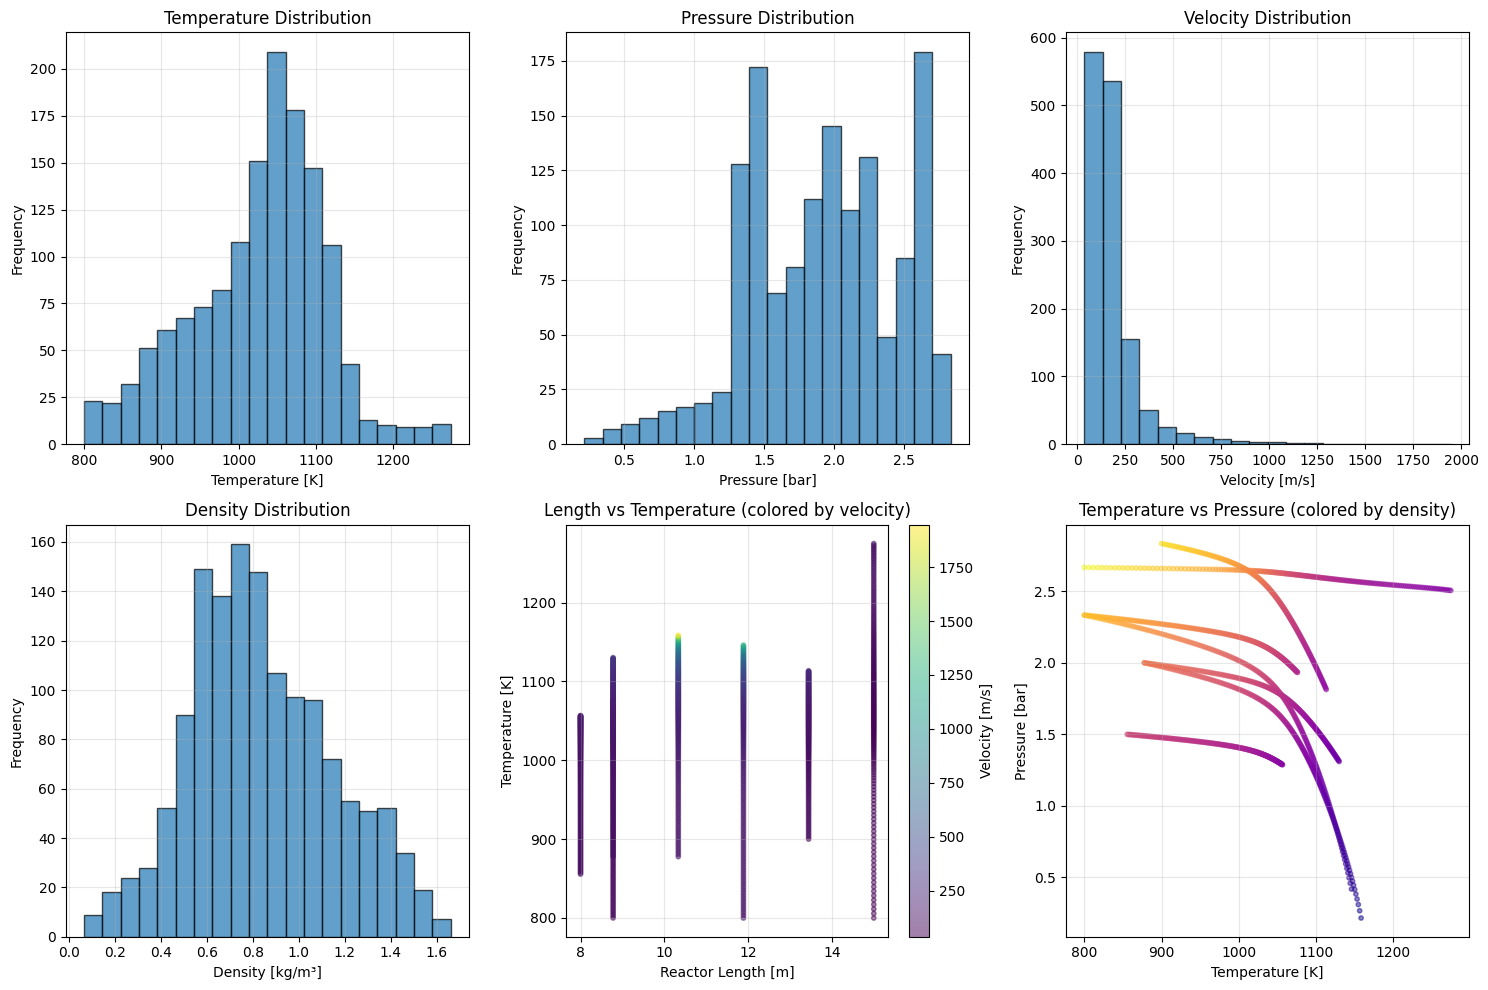

[OK] Data exploration visualizations displayed above


In [6]:
# Quick visualization of parameter distributions
if dataset is not None:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Temperature distribution
    axes[0, 0].hist(dataset['temperature_K'], bins=20, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Temperature [K]')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Temperature Distribution')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Pressure distribution
    axes[0, 1].hist(dataset['pressure_Pa']/1e5, bins=20, edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Pressure [bar]')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Pressure Distribution')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Velocity distribution
    axes[0, 2].hist(dataset['velocity_ms'], bins=20, edgecolor='black', alpha=0.7)
    axes[0, 2].set_xlabel('Velocity [m/s]')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].set_title('Velocity Distribution')
    axes[0, 2].grid(True, alpha=0.3)
    
    # Density distribution
    axes[1, 0].hist(dataset['density_kgm3'], bins=20, edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Density [kg/m³]')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Density Distribution')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Reactor length vs temperature
    scatter = axes[1, 1].scatter(dataset['reactor_length_m'], dataset['temperature_K'], 
                                 c=dataset['velocity_ms'], cmap='viridis', alpha=0.5, s=10)
    axes[1, 1].set_xlabel('Reactor Length [m]')
    axes[1, 1].set_ylabel('Temperature [K]')
    axes[1, 1].set_title('Length vs Temperature (colored by velocity)')
    axes[1, 1].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[1, 1], label='Velocity [m/s]')
    
    # Pressure vs temperature
    axes[1, 2].scatter(dataset['temperature_K'], dataset['pressure_Pa']/1e5, 
                      c=dataset['density_kgm3'], cmap='plasma', alpha=0.5, s=10)
    axes[1, 2].set_xlabel('Temperature [K]')
    axes[1, 2].set_ylabel('Pressure [bar]')
    axes[1, 2].set_title('Temperature vs Pressure (colored by density)')
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("[OK] Data exploration visualizations displayed above")

## Step 6: Comprehensive Data Visualization

Explore your training data with detailed visualizations including:
- Parameter distributions
- Correlation analysis
- Feature relationships
- Data quality checks

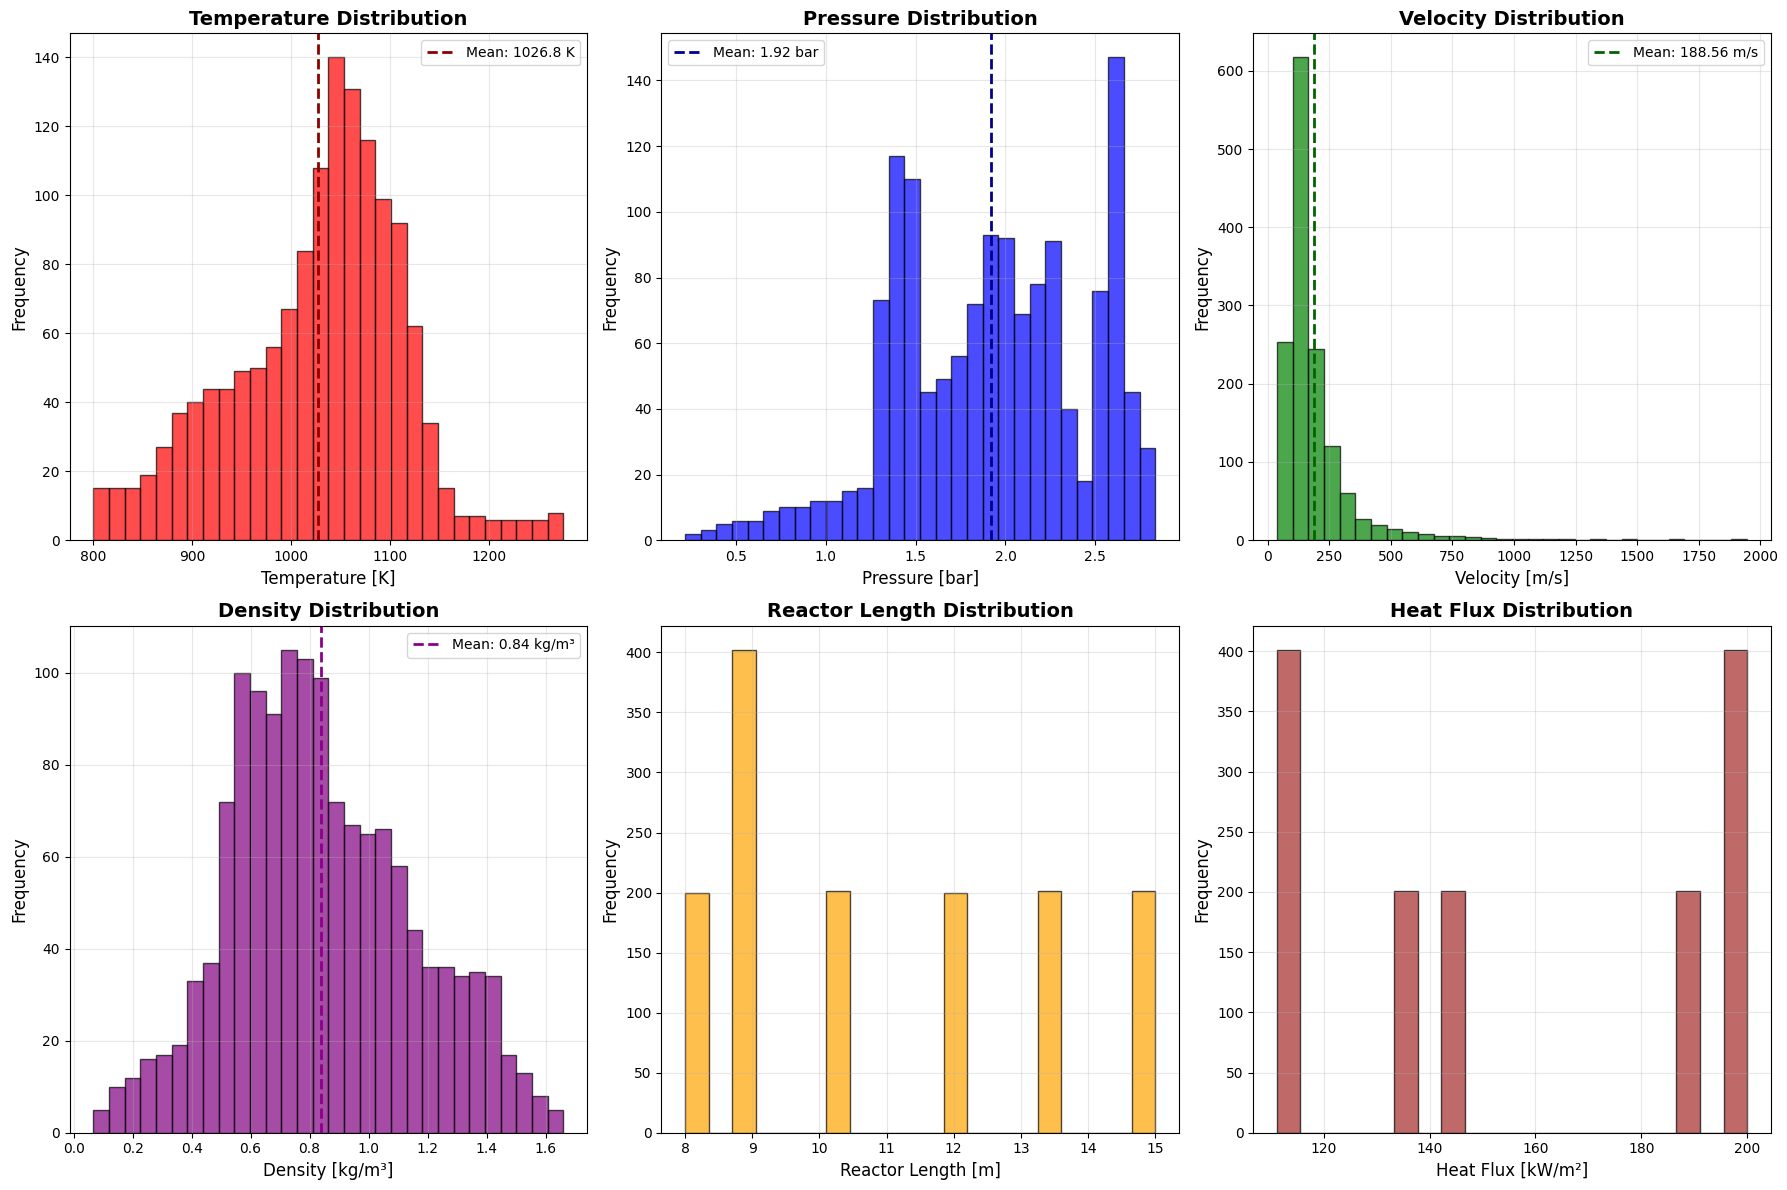

[OK] Parameter distributions displayed above


In [7]:
# Comprehensive data visualization
if dataset is not None:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Set style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # 1. Parameter Distributions
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Temperature distribution
    axes[0, 0].hist(dataset['temperature_K'], bins=30, edgecolor='black', alpha=0.7, color='red')
    axes[0, 0].set_xlabel('Temperature [K]', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)
    axes[0, 0].set_title('Temperature Distribution', fontsize=14, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axvline(dataset['temperature_K'].mean(), color='darkred', linestyle='--', 
                       linewidth=2, label=f'Mean: {dataset["temperature_K"].mean():.1f} K')
    axes[0, 0].legend()
    
    # Pressure distribution
    axes[0, 1].hist(dataset['pressure_Pa']/1e5, bins=30, edgecolor='black', alpha=0.7, color='blue')
    axes[0, 1].set_xlabel('Pressure [bar]', fontsize=12)
    axes[0, 1].set_ylabel('Frequency', fontsize=12)
    axes[0, 1].set_title('Pressure Distribution', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axvline((dataset['pressure_Pa']/1e5).mean(), color='darkblue', linestyle='--', 
                       linewidth=2, label=f'Mean: {(dataset["pressure_Pa"]/1e5).mean():.2f} bar')
    axes[0, 1].legend()
    
    # Velocity distribution
    axes[0, 2].hist(dataset['velocity_ms'], bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[0, 2].set_xlabel('Velocity [m/s]', fontsize=12)
    axes[0, 2].set_ylabel('Frequency', fontsize=12)
    axes[0, 2].set_title('Velocity Distribution', fontsize=14, fontweight='bold')
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].axvline(dataset['velocity_ms'].mean(), color='darkgreen', linestyle='--', 
                       linewidth=2, label=f'Mean: {dataset["velocity_ms"].mean():.2f} m/s')
    axes[0, 2].legend()
    
    # Density distribution
    axes[1, 0].hist(dataset['density_kgm3'], bins=30, edgecolor='black', alpha=0.7, color='purple')
    axes[1, 0].set_xlabel('Density [kg/m³]', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)
    axes[1, 0].set_title('Density Distribution', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axvline(dataset['density_kgm3'].mean(), color='darkmagenta', linestyle='--', 
                       linewidth=2, label=f'Mean: {dataset["density_kgm3"].mean():.2f} kg/m³')
    axes[1, 0].legend()
    
    # Reactor length distribution
    if 'reactor_length_m' in dataset.columns:
        axes[1, 1].hist(dataset['reactor_length_m'], bins=20, edgecolor='black', alpha=0.7, color='orange')
        axes[1, 1].set_xlabel('Reactor Length [m]', fontsize=12)
        axes[1, 1].set_ylabel('Frequency', fontsize=12)
        axes[1, 1].set_title('Reactor Length Distribution', fontsize=14, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3)
    
    # Heat flux distribution
    if 'heat_flux_Wm2' in dataset.columns:
        axes[1, 2].hist(dataset['heat_flux_Wm2']/1e3, bins=20, edgecolor='black', alpha=0.7, color='brown')
        axes[1, 2].set_xlabel('Heat Flux [kW/m²]', fontsize=12)
        axes[1, 2].set_ylabel('Frequency', fontsize=12)
        axes[1, 2].set_title('Heat Flux Distribution', fontsize=14, fontweight='bold')
        axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("[OK] Parameter distributions displayed above")

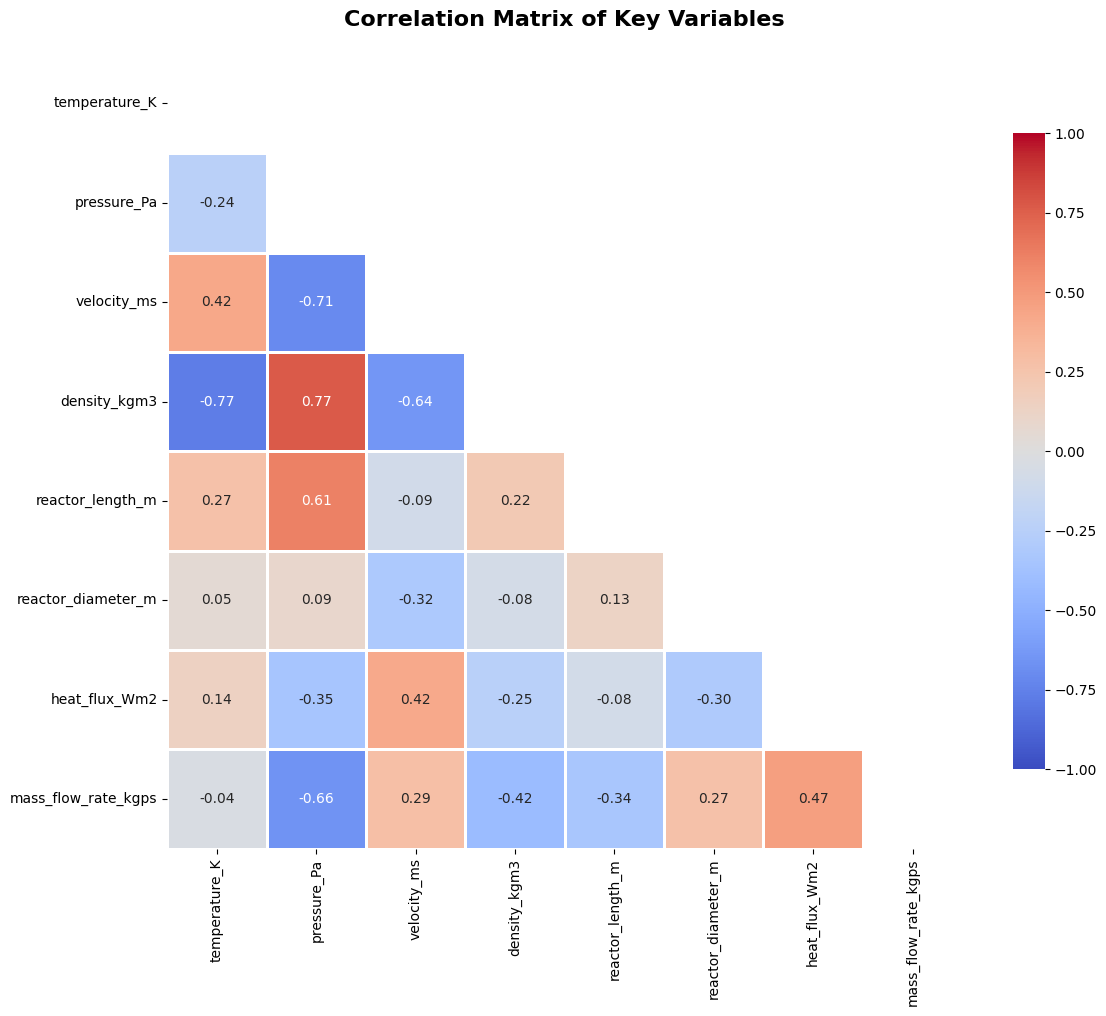

[OK] Correlation matrix displayed above

Strongest correlations (|r| > 0.7):
  - temperature_K vs density_kgm3: -0.773
  - pressure_Pa vs velocity_ms: -0.707
  - pressure_Pa vs density_kgm3: 0.770


In [8]:
# 2. Correlation Matrix for Key Variables
if dataset is not None:
    # Select key variables for correlation
    key_vars = ['temperature_K', 'pressure_Pa', 'velocity_ms', 'density_kgm3']
    if 'reactor_length_m' in dataset.columns:
        key_vars.append('reactor_length_m')
    if 'reactor_diameter_m' in dataset.columns:
        key_vars.append('reactor_diameter_m')
    if 'heat_flux_Wm2' in dataset.columns:
        key_vars.append('heat_flux_Wm2')
    if 'mass_flow_rate_kgps' in dataset.columns:
        key_vars.append('mass_flow_rate_kgps')
    
    # Filter to only include columns that exist
    key_vars = [v for v in key_vars if v in dataset.columns]
    
    # Calculate correlation matrix
    corr_matrix = dataset[key_vars].corr()
    
    # Create heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1)
    plt.title('Correlation Matrix of Key Variables', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    print("[OK] Correlation matrix displayed above")
    print(f"\nStrongest correlations (|r| > 0.7):")
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.7:
                print(f"  - {corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: {corr_val:.3f}")

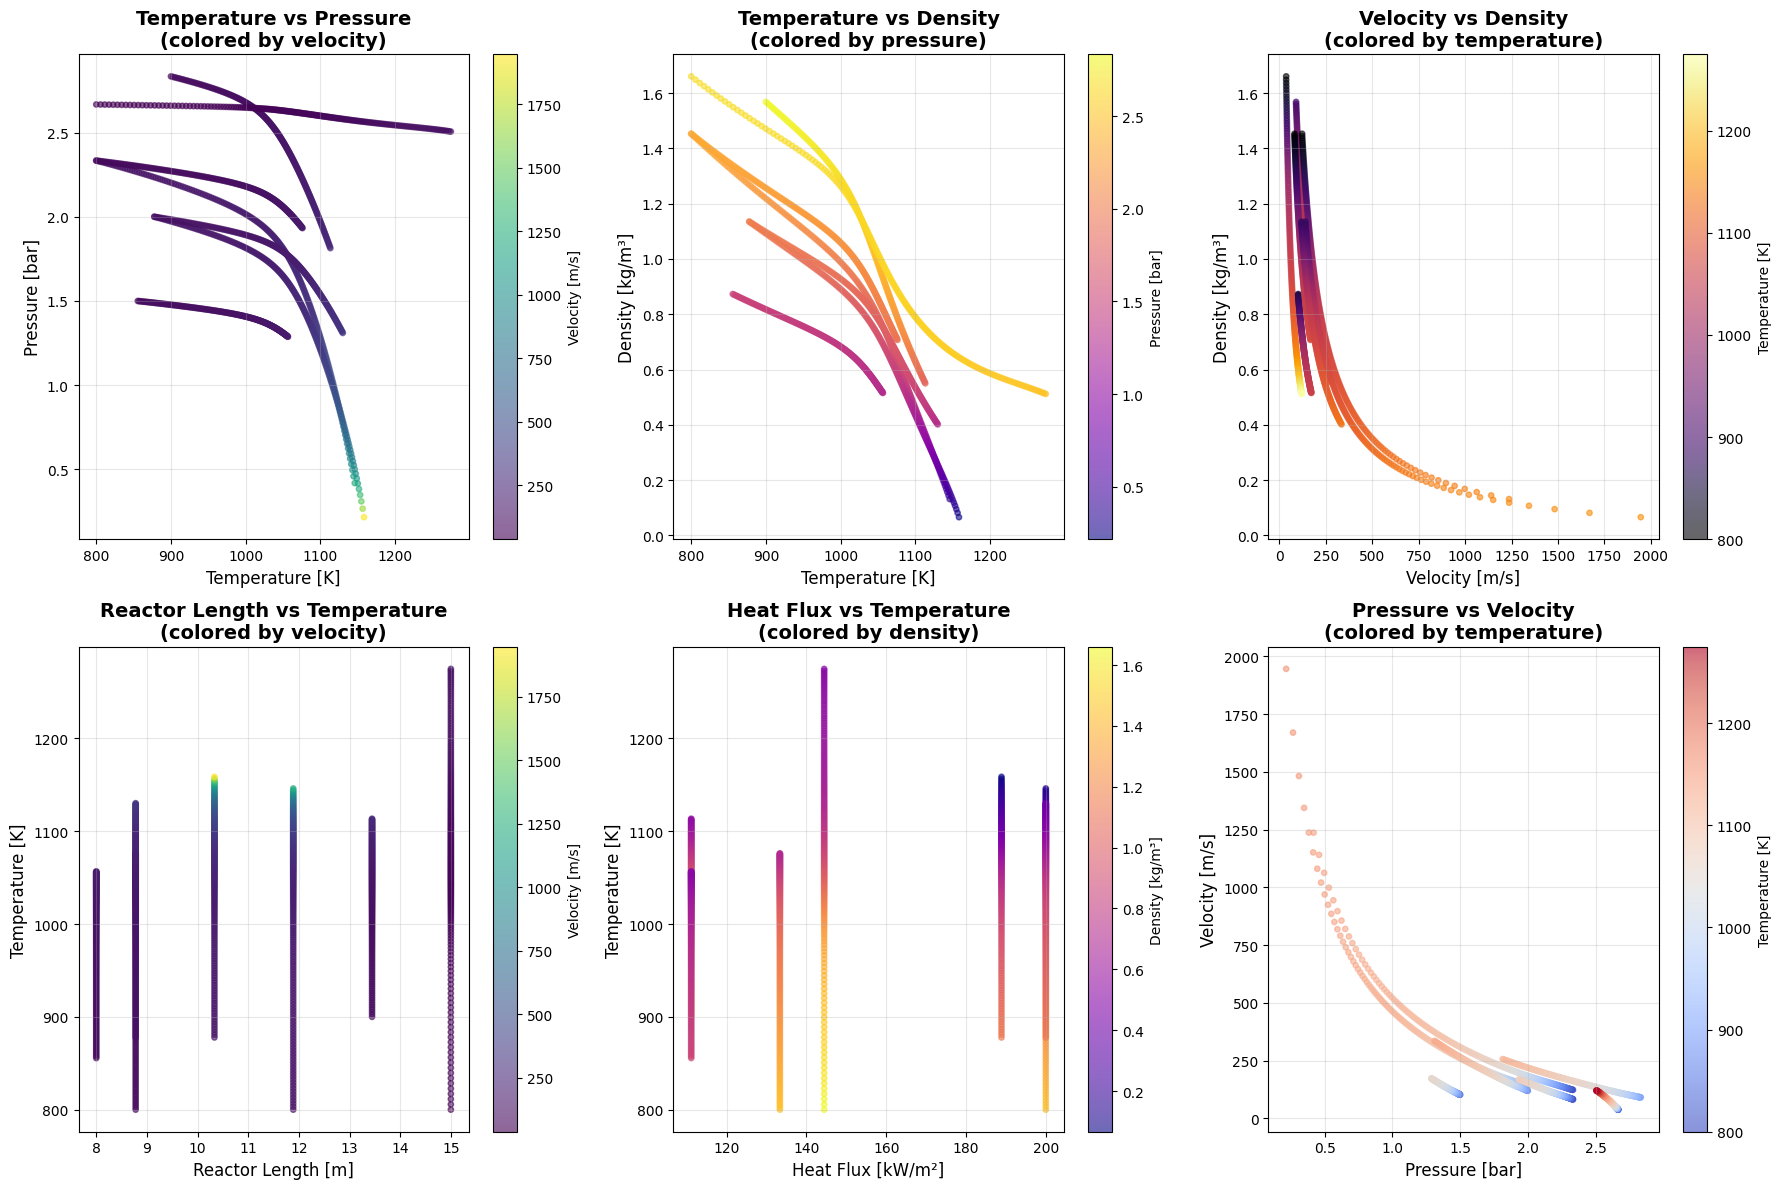

[OK] Feature relationship plots displayed above


In [9]:
# 3. Feature Relationships - Scatter Plots
if dataset is not None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Temperature vs Pressure (colored by velocity)
    scatter1 = axes[0, 0].scatter(dataset['temperature_K'], dataset['pressure_Pa']/1e5, 
                                  c=dataset['velocity_ms'], cmap='viridis', alpha=0.6, s=15)
    axes[0, 0].set_xlabel('Temperature [K]', fontsize=12)
    axes[0, 0].set_ylabel('Pressure [bar]', fontsize=12)
    axes[0, 0].set_title('Temperature vs Pressure\n(colored by velocity)', fontsize=14, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[0, 0], label='Velocity [m/s]')
    
    # Temperature vs Density (colored by pressure)
    scatter2 = axes[0, 1].scatter(dataset['temperature_K'], dataset['density_kgm3'], 
                                  c=dataset['pressure_Pa']/1e5, cmap='plasma', alpha=0.6, s=15)
    axes[0, 1].set_xlabel('Temperature [K]', fontsize=12)
    axes[0, 1].set_ylabel('Density [kg/m³]', fontsize=12)
    axes[0, 1].set_title('Temperature vs Density\n(colored by pressure)', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[0, 1], label='Pressure [bar]')
    
    # Velocity vs Density (colored by temperature)
    scatter3 = axes[0, 2].scatter(dataset['velocity_ms'], dataset['density_kgm3'], 
                                  c=dataset['temperature_K'], cmap='inferno', alpha=0.6, s=15)
    axes[0, 2].set_xlabel('Velocity [m/s]', fontsize=12)
    axes[0, 2].set_ylabel('Density [kg/m³]', fontsize=12)
    axes[0, 2].set_title('Velocity vs Density\n(colored by temperature)', fontsize=14, fontweight='bold')
    axes[0, 2].grid(True, alpha=0.3)
    plt.colorbar(scatter3, ax=axes[0, 2], label='Temperature [K]')
    
    # Reactor length vs Temperature
    if 'reactor_length_m' in dataset.columns:
        scatter4 = axes[1, 0].scatter(dataset['reactor_length_m'], dataset['temperature_K'], 
                                      c=dataset['velocity_ms'], cmap='viridis', alpha=0.6, s=15)
        axes[1, 0].set_xlabel('Reactor Length [m]', fontsize=12)
        axes[1, 0].set_ylabel('Temperature [K]', fontsize=12)
        axes[1, 0].set_title('Reactor Length vs Temperature\n(colored by velocity)', fontsize=14, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3)
        plt.colorbar(scatter4, ax=axes[1, 0], label='Velocity [m/s]')
    
    # Heat flux vs Temperature
    if 'heat_flux_Wm2' in dataset.columns:
        scatter5 = axes[1, 1].scatter(dataset['heat_flux_Wm2']/1e3, dataset['temperature_K'], 
                                      c=dataset['density_kgm3'], cmap='plasma', alpha=0.6, s=15)
        axes[1, 1].set_xlabel('Heat Flux [kW/m²]', fontsize=12)
        axes[1, 1].set_ylabel('Temperature [K]', fontsize=12)
        axes[1, 1].set_title('Heat Flux vs Temperature\n(colored by density)', fontsize=14, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3)
        plt.colorbar(scatter5, ax=axes[1, 1], label='Density [kg/m³]')
    
    # Pressure vs Velocity
    scatter6 = axes[1, 2].scatter(dataset['pressure_Pa']/1e5, dataset['velocity_ms'], 
                                  c=dataset['temperature_K'], cmap='coolwarm', alpha=0.6, s=15)
    axes[1, 2].set_xlabel('Pressure [bar]', fontsize=12)
    axes[1, 2].set_ylabel('Velocity [m/s]', fontsize=12)
    axes[1, 2].set_title('Pressure vs Velocity\n(colored by temperature)', fontsize=14, fontweight='bold')
    axes[1, 2].grid(True, alpha=0.3)
    plt.colorbar(scatter6, ax=axes[1, 2], label='Temperature [K]')
    
    plt.tight_layout()
    plt.show()
    
    print("[OK] Feature relationship plots displayed above")

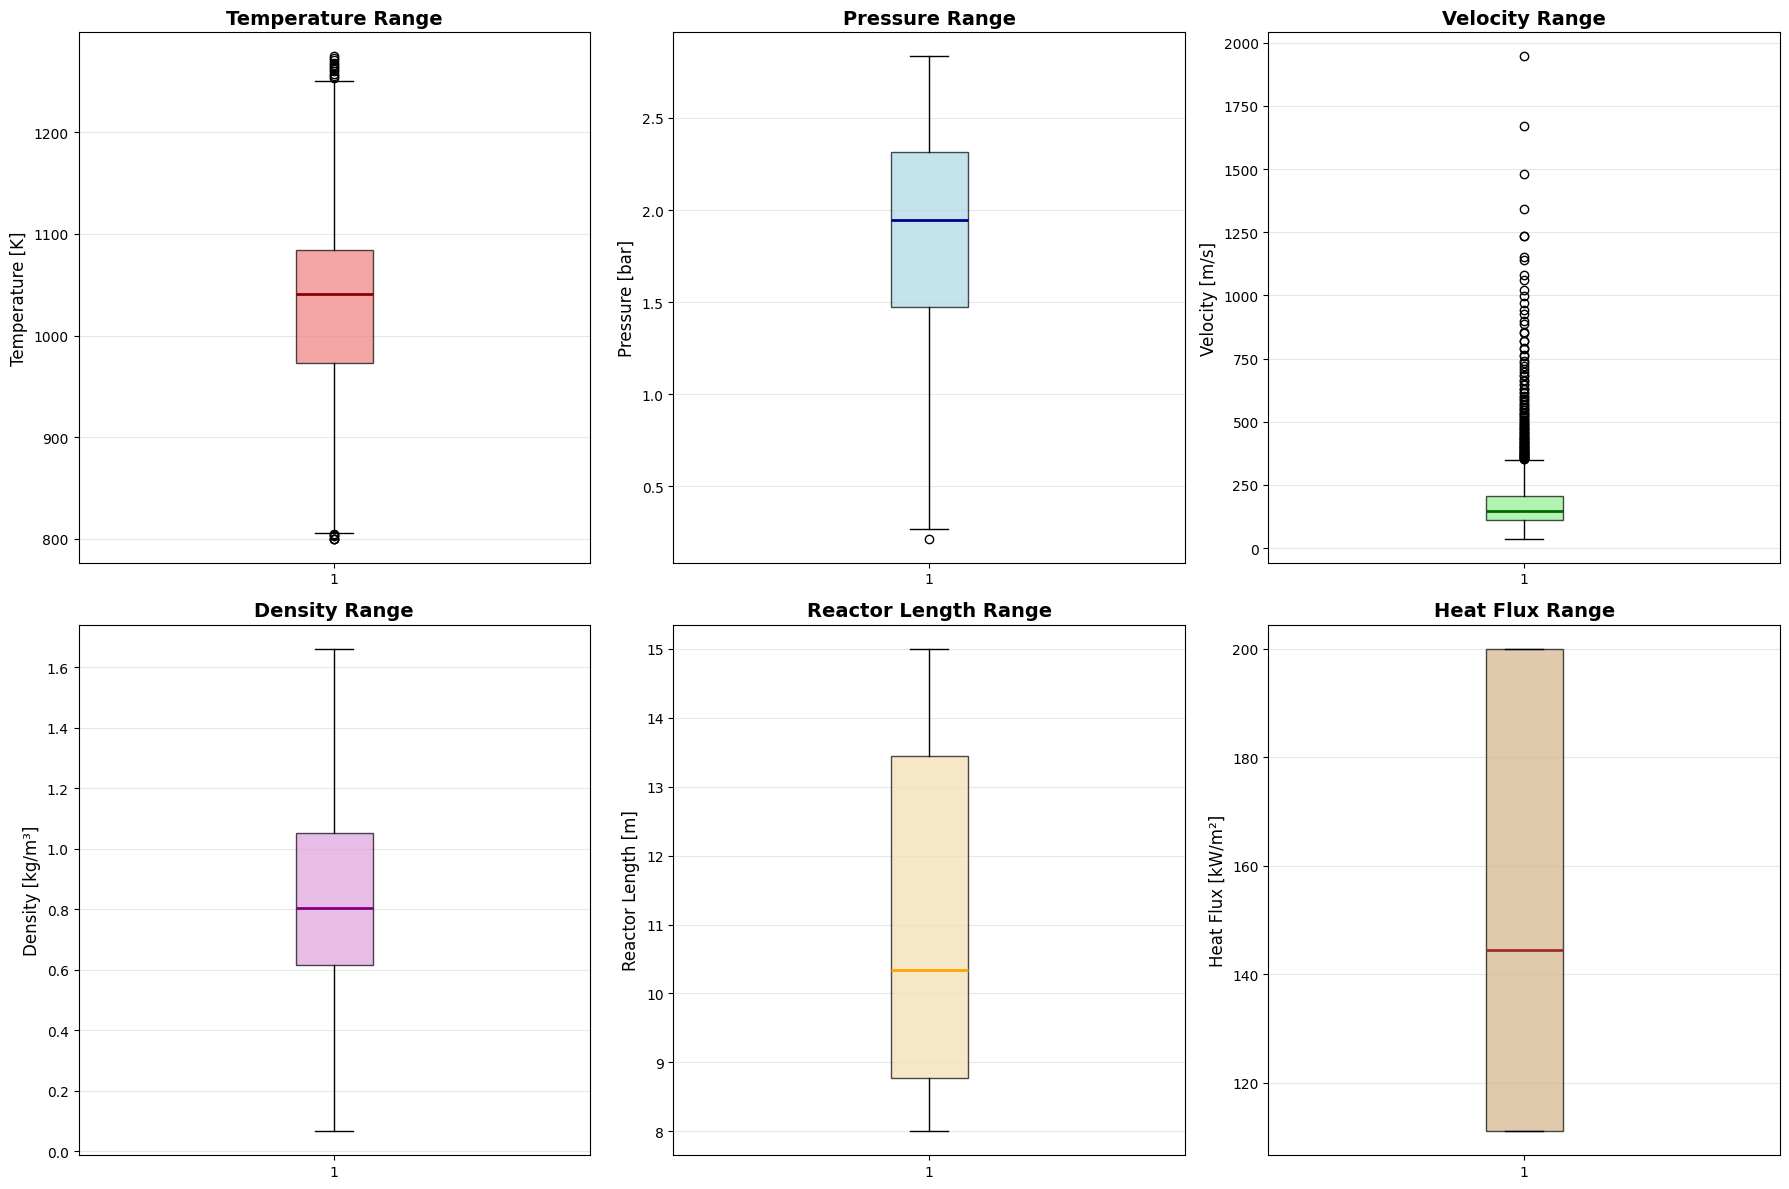

[OK] Box plots for parameter ranges displayed above


In [10]:
# 4. Box Plots for Parameter Ranges
if dataset is not None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Temperature box plot
    axes[0, 0].boxplot(dataset['temperature_K'], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightcoral', alpha=0.7),
                       medianprops=dict(color='darkred', linewidth=2))
    axes[0, 0].set_ylabel('Temperature [K]', fontsize=12)
    axes[0, 0].set_title('Temperature Range', fontsize=14, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Pressure box plot
    axes[0, 1].boxplot(dataset['pressure_Pa']/1e5, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7),
                       medianprops=dict(color='darkblue', linewidth=2))
    axes[0, 1].set_ylabel('Pressure [bar]', fontsize=12)
    axes[0, 1].set_title('Pressure Range', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Velocity box plot
    axes[0, 2].boxplot(dataset['velocity_ms'], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightgreen', alpha=0.7),
                       medianprops=dict(color='darkgreen', linewidth=2))
    axes[0, 2].set_ylabel('Velocity [m/s]', fontsize=12)
    axes[0, 2].set_title('Velocity Range', fontsize=14, fontweight='bold')
    axes[0, 2].grid(True, alpha=0.3, axis='y')
    
    # Density box plot
    axes[1, 0].boxplot(dataset['density_kgm3'], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='plum', alpha=0.7),
                       medianprops=dict(color='purple', linewidth=2))
    axes[1, 0].set_ylabel('Density [kg/m³]', fontsize=12)
    axes[1, 0].set_title('Density Range', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Reactor length box plot
    if 'reactor_length_m' in dataset.columns:
        axes[1, 1].boxplot(dataset['reactor_length_m'], vert=True, patch_artist=True,
                          boxprops=dict(facecolor='wheat', alpha=0.7),
                          medianprops=dict(color='orange', linewidth=2))
        axes[1, 1].set_ylabel('Reactor Length [m]', fontsize=12)
        axes[1, 1].set_title('Reactor Length Range', fontsize=14, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    # Heat flux box plot
    if 'heat_flux_Wm2' in dataset.columns:
        axes[1, 2].boxplot(dataset['heat_flux_Wm2']/1e3, vert=True, patch_artist=True,
                          boxprops=dict(facecolor='tan', alpha=0.7),
                          medianprops=dict(color='brown', linewidth=2))
        axes[1, 2].set_ylabel('Heat Flux [kW/m²]', fontsize=12)
        axes[1, 2].set_title('Heat Flux Range', fontsize=14, fontweight='bold')
        axes[1, 2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("[OK] Box plots for parameter ranges displayed above")

In [11]:
# 5. Data Quality Checks
if dataset is not None:
    print("=" * 60)
    print("DATA QUALITY CHECKS")
    print("=" * 60)
    
    # Check for missing values
    missing = dataset.isnull().sum()
    missing_pct = (missing / len(dataset)) * 100
    print("\nMissing Values:")
    if missing.sum() == 0:
        print("  [OK] No missing values found!")
    else:
        print("  [WARNING] Missing values detected:")
        for col in missing[missing > 0].index:
            print(f"    - {col}: {missing[col]} ({missing_pct[col]:.2f}%)")
    
    # Check for infinite values
    inf_cols = []
    for col in dataset.select_dtypes(include=[np.number]).columns:
        if np.isinf(dataset[col]).any():
            inf_cols.append(col)
    
    print("\nInfinite Values:")
    if len(inf_cols) == 0:
        print("  [OK] No infinite values found!")
    else:
        print(f"  [WARNING] Infinite values found in {len(inf_cols)} columns:")
        for col in inf_cols:
            print(f"    - {col}: {np.isinf(dataset[col]).sum()} values")
    
    # Check for outliers (using IQR method)
    print("\nOutlier Detection (IQR method):")
    key_numeric = ['temperature_K', 'pressure_Pa', 'velocity_ms', 'density_kgm3']
    key_numeric = [c for c in key_numeric if c in dataset.columns]
    
    for col in key_numeric:
        Q1 = dataset[col].quantile(0.25)
        Q3 = dataset[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((dataset[col] < lower_bound) | (dataset[col] > upper_bound)).sum()
        outlier_pct = (outliers / len(dataset)) * 100
        
        if outliers > 0:
            print(f"  - {col}: {outliers} outliers ({outlier_pct:.2f}%)")
        else:
            print(f"  - {col}: No outliers detected")
    
    # Check value ranges
    print("\nValue Ranges:")
    for col in key_numeric:
        print(f"  - {col}:")
        print(f"    Min: {dataset[col].min():.2e}, Max: {dataset[col].max():.2e}")
        print(f"    Mean: {dataset[col].mean():.2e}, Std: {dataset[col].std():.2e}")
    
    print("\n[OK] Data quality checks completed")

DATA QUALITY CHECKS

Missing Values:
  [OK] No missing values found!

Infinite Values:
  [OK] No infinite values found!

Outlier Detection (IQR method):
  - temperature_K: 17 outliers (1.21%)
  - pressure_Pa: 1 outliers (0.07%)
  - velocity_ms: 112 outliers (7.97%)
  - density_kgm3: No outliers detected

Value Ranges:
  - temperature_K:
    Min: 8.00e+02, Max: 1.27e+03
    Mean: 1.03e+03, Std: 8.67e+01
  - pressure_Pa:
    Min: 2.17e+04, Max: 2.83e+05
    Mean: 1.92e+05, Std: 5.29e+04
  - velocity_ms:
    Min: 3.73e+01, Max: 1.95e+03
    Mean: 1.89e+02, Std: 1.63e+02
  - density_kgm3:
    Min: 6.62e-02, Max: 1.66e+00
    Mean: 8.39e-01, Std: 3.11e-01

[OK] Data quality checks completed


## Step 7: Species Analysis (Optional)

If you want to explore species concentrations in your dataset:

Found 153 species in dataset


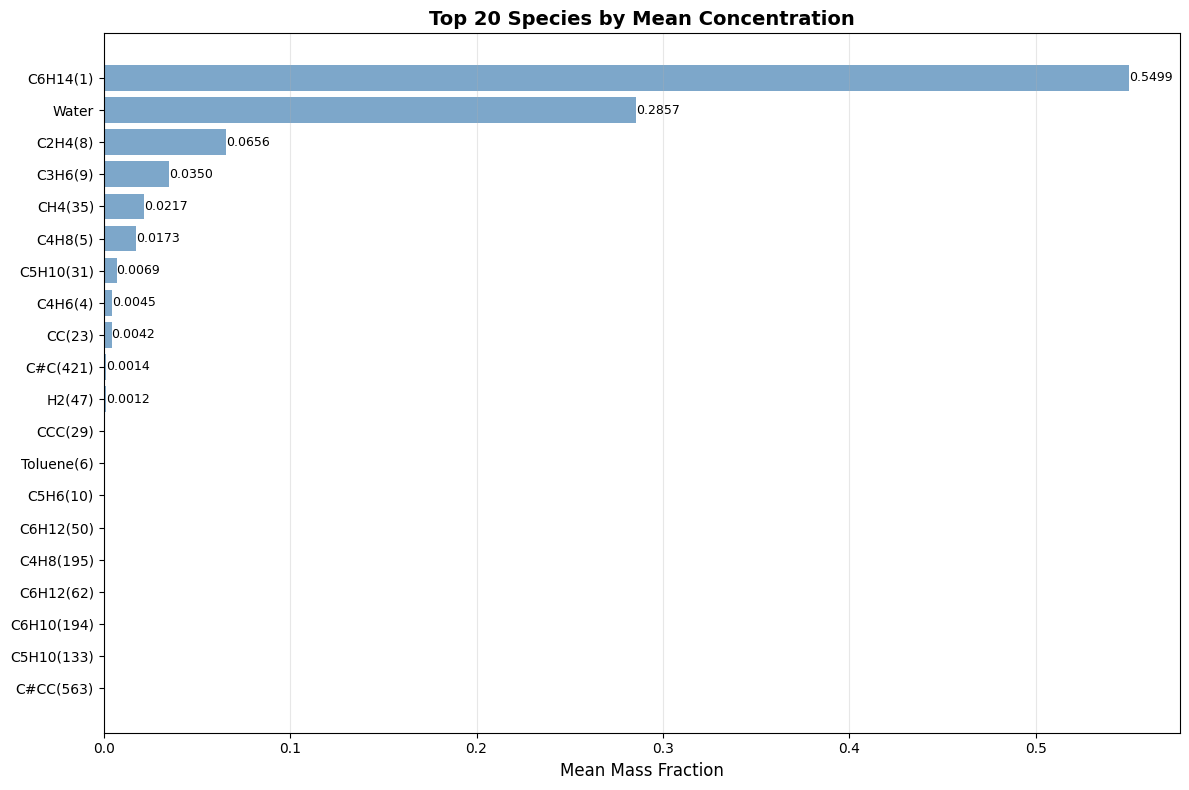


[OK] Top 20 species by concentration:
   1. C6H14(1)            : 0.549901
   2. Water               : 0.285714
   3. C2H4(8)             : 0.065561
   4. C3H6(9)             : 0.034956
   5. CH4(35)             : 0.021747
   6. C4H8(5)             : 0.017287
   7. C5H10(31)           : 0.006875
   8. C4H6(4)             : 0.004488
   9. CC(23)              : 0.004228
  10. C#C(421)            : 0.001419
  11. H2(47)              : 0.001235
  12. CCC(29)             : 0.000931
  13. Toluene(6)          : 0.000858
  14. C5H6(10)            : 0.000844
  15. C6H12(50)           : 0.000831
  16. C4H8(195)           : 0.000691
  17. C6H12(62)           : 0.000627
  18. C6H10(194)          : 0.000523
  19. C5H10(133)          : 0.000333
  20. C#CC(563)           : 0.000308


In [12]:
# Species concentration analysis
if dataset is not None:
    # Find species columns
    species_cols = [c for c in dataset.columns if c.startswith('Y_')]
    
    if len(species_cols) > 0:
        print(f"Found {len(species_cols)} species in dataset")
        
        # Calculate mean concentrations
        mean_concentrations = {}
        for col in species_cols:
            species_name = col.replace('Y_', '')
            mean_concentrations[species_name] = dataset[col].mean()
        
        # Sort by concentration
        sorted_species = sorted(mean_concentrations.items(), key=lambda x: x[1], reverse=True)
        
        # Plot top 20 species
        top_n = min(20, len(sorted_species))
        top_species = sorted_species[:top_n]
        
        fig, ax = plt.subplots(figsize=(12, 8))
        species_names = [s[0] for s in top_species]
        concentrations = [s[1] for s in top_species]
        
        bars = ax.barh(range(len(species_names)), concentrations, color='steelblue', alpha=0.7)
        ax.set_yticks(range(len(species_names)))
        ax.set_yticklabels(species_names, fontsize=10)
        ax.set_xlabel('Mean Mass Fraction', fontsize=12)
        ax.set_title(f'Top {top_n} Species by Mean Concentration', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        ax.invert_yaxis()
        
        # Add value labels on bars
        for i, (bar, val) in enumerate(zip(bars, concentrations)):
            if val > 0.001:  # Only label significant values
                ax.text(val, i, f'{val:.4f}', va='center', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n[OK] Top {top_n} species by concentration:")
        for i, (species, conc) in enumerate(top_species, 1):
            print(f"  {i:2d}. {species:20s}: {conc:.6f}")
    else:
        print("No species columns found in dataset")

## Summary

Your training data has been generated and visualized! Key insights:

1. **Parameter Coverage**: Check distributions to ensure good coverage of parameter space
2. **Correlations**: Identify strongly correlated features (may need feature engineering)
3. **Data Quality**: Verify no missing/infinite values or excessive outliers
4. **Species Diversity**: Ensure all important species are present in sufficient concentrations

### Next Steps:
1. **Train ML Models**: Use the generated dataset to train surrogate models
2. **Feature Engineering**: Consider transformations based on correlation analysis
3. **Data Augmentation**: Generate more data if coverage is insufficient
4. **Validation Split**: Reserve 20-30% of data for model validation